# Module 2 — NHS Digital Eating Disorder Admissions by Subtype (2024-25)

**Goal:** analyze real, official NHS Digital hospital admission data for England, broken down by eating disorder subtype (ICD-10 F50.0–F50.9).

**Source:** NHS Digital, *Hospital Admitted Patient Care Activity 2024-25*, diagnosis summary file.
https://digital.nhs.uk/data-and-information/publications/statistical/hospital-admitted-patient-care-activity/2024-25

## 1. Load and clean the raw NHS file

The raw file is long-format: `UID, Code, Category, Attribute, Value`. We pivot it into a clean, one-row-per-subtype table.

In [10]:
import sys, os

print("cwd:", os.getcwd())
print("contents:", os.listdir('.'))

# make the fix bulletproof regardless of where Jupyter thinks it is
if os.path.isdir('src'):
    src_path = os.path.abspath('src')
elif os.path.isdir('../src'):
    src_path = os.path.abspath('../src')
else:
    raise FileNotFoundError("Can't find src/ from here — check the printed cwd/contents above")

sys.path.insert(0, src_path)
print("added to path:", src_path)

cwd: c:\PROJECTSSSSS\uk-ed-analytics
contents: ['.git', '.gitignore', 'dashboard', 'data', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'sql', 'src', 'tests', 'venv']
added to path: c:\PROJECTSSSSS\uk-ed-analytics\src


In [1]:
import sys
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append('src')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from load_nhs_diagnosis_data import main as load_main
load_main()

Saved eating disorder subtype table -> data/processed/nhs_ed_subtypes_2024-25.csv
Attribute   Code                                    diagnosis_label  FCE_SUM  \
0            F50                       All Eating Disorders (total)   7884.0   
1          F50.0                                   Anorexia Nervosa   4067.0   
2          F50.1                          Atypical Anorexia Nervosa     96.0   
3          F50.2                                    Bulimia Nervosa    216.0   
4          F50.3                           Atypical Bulimia Nervosa      9.0   
5          F50.5                           Vomiting (psychological)    113.0   
6          F50.8  Other Eating Disorders (incl. Binge Eating Dis...   1115.0   
7          F50.9                       Eating Disorder, Unspecified   2268.0   

Attribute  FAE_SUM  FCE_Male_Sum  FCE_Female_Sum  
0           4498.0         827.0          7017.0  
1           1914.0         220.0          3822.0  
2             54.0          18.0            

In [12]:
subtypes = pd.read_csv('data/processed/nhs_ed_subtypes_2024-25.csv')
subtypes[['Code', 'diagnosis_label', 'FCE_SUM', 'FAE_SUM', 'FCE_Male_Sum', 'FCE_Female_Sum']]

,Code,diagnosis_label,FCE_SUM,FAE_SUM,FCE_Male_Sum,FCE_Female_Sum
0,F50,All Eating Disorders (total),7884.0,4498.0,827.0,7017.0
1,F50.0,Anorexia Nervosa,4067.0,1914.0,220.0,3822.0
2,F50.1,Atypical Anorexia Nervosa,96.0,54.0,18.0,78.0
3,F50.2,Bulimia Nervosa,216.0,103.0,25.0,191.0
4,F50.3,Atypical Bulimia Nervosa,9.0,2.0,0.0,9.0
5,F50.5,Vomiting (psychological),113.0,52.0,24.0,89.0
6,F50.8,Other Eating Disorders (incl. Binge Eating Dis...,1115.0,738.0,319.0,793.0
7,F50.9,"Eating Disorder, Unspecified",2268.0,1635.0,221.0,2035.0


## 2. Subtype breakdown

In [ ]:
total = subtypes.loc[subtypes['Code']=='F50', 'FCE_SUM'].values[0]
d = subtypes[subtypes['Code'] != 'F50'].sort_values('FCE_SUM', ascending=False).copy()
d['pct_of_total'] = (d['FCE_SUM'] / total * 100).round(1)
d['pct_female'] = (d['FCE_Female_Sum'] / d['FCE_SUM'] * 100).round(1)
print(f"Total eating disorder episodes, England 2024-25: {total:,.0f}\n")
d[['diagnosis_label', 'FCE_SUM', 'pct_of_total', 'pct_female']]

Total eating disorder episodes, England 2024-25: 7,884



,diagnosis_label,FCE_SUM,pct_of_total,pct_female
1,Anorexia Nervosa,4067.0,51.6,94.0
7,"Eating Disorder, Unspecified",2268.0,28.8,89.7
6,Other Eating Disorders (incl. Binge Eating Dis...,1115.0,14.1,71.1
3,Bulimia Nervosa,216.0,2.7,88.4
5,Vomiting (psychological),113.0,1.4,78.8
2,Atypical Anorexia Nervosa,96.0,1.2,81.2
4,Atypical Bulimia Nervosa,9.0,0.1,100.0


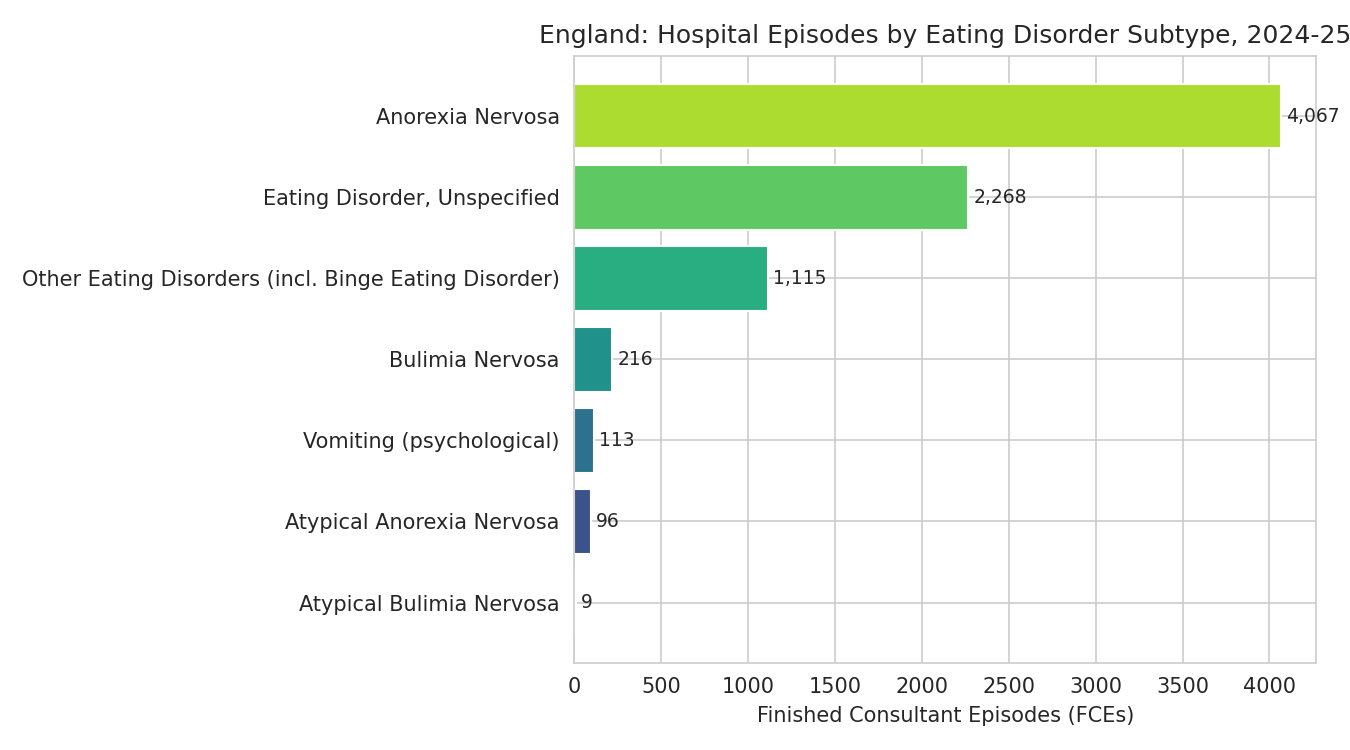

In [ ]:
from IPython.display import Image
Image('reports/figures/nhs_subtype_admissions.png')

**Reading this:** Anorexia Nervosa is the single largest subtype (51.6% of all episodes, 94% female). Notably, "Eating Disorder, Unspecified" is the *second* largest category (28.8%) — a genuine finding about diagnostic coding practice, not just clinical prevalence: a large share of hospital episodes aren't coded to a specific subtype.

## 3. Gender split by subtype

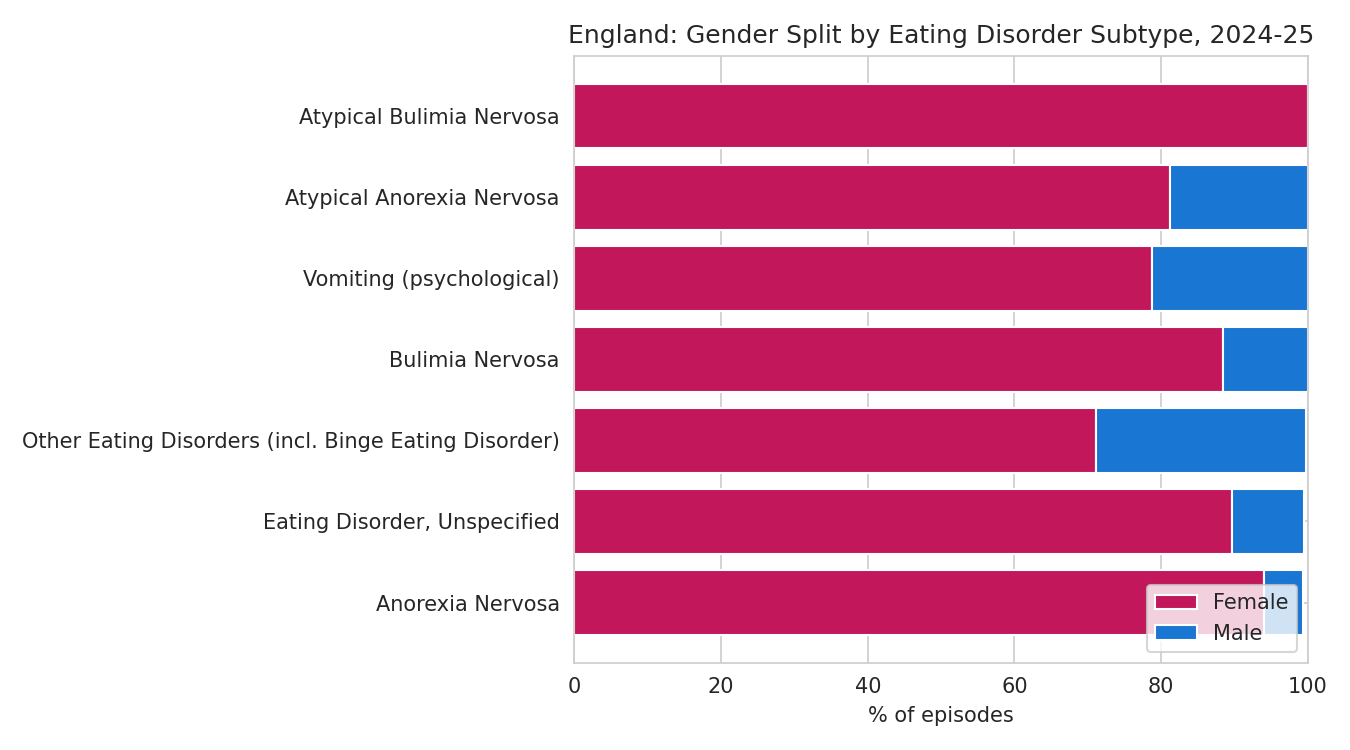

In [ ]:
Image('reports/figures/nhs_gender_split.png')

## 4. Age pattern by subtype

Which ages are most affected, and does the pattern differ by subtype?

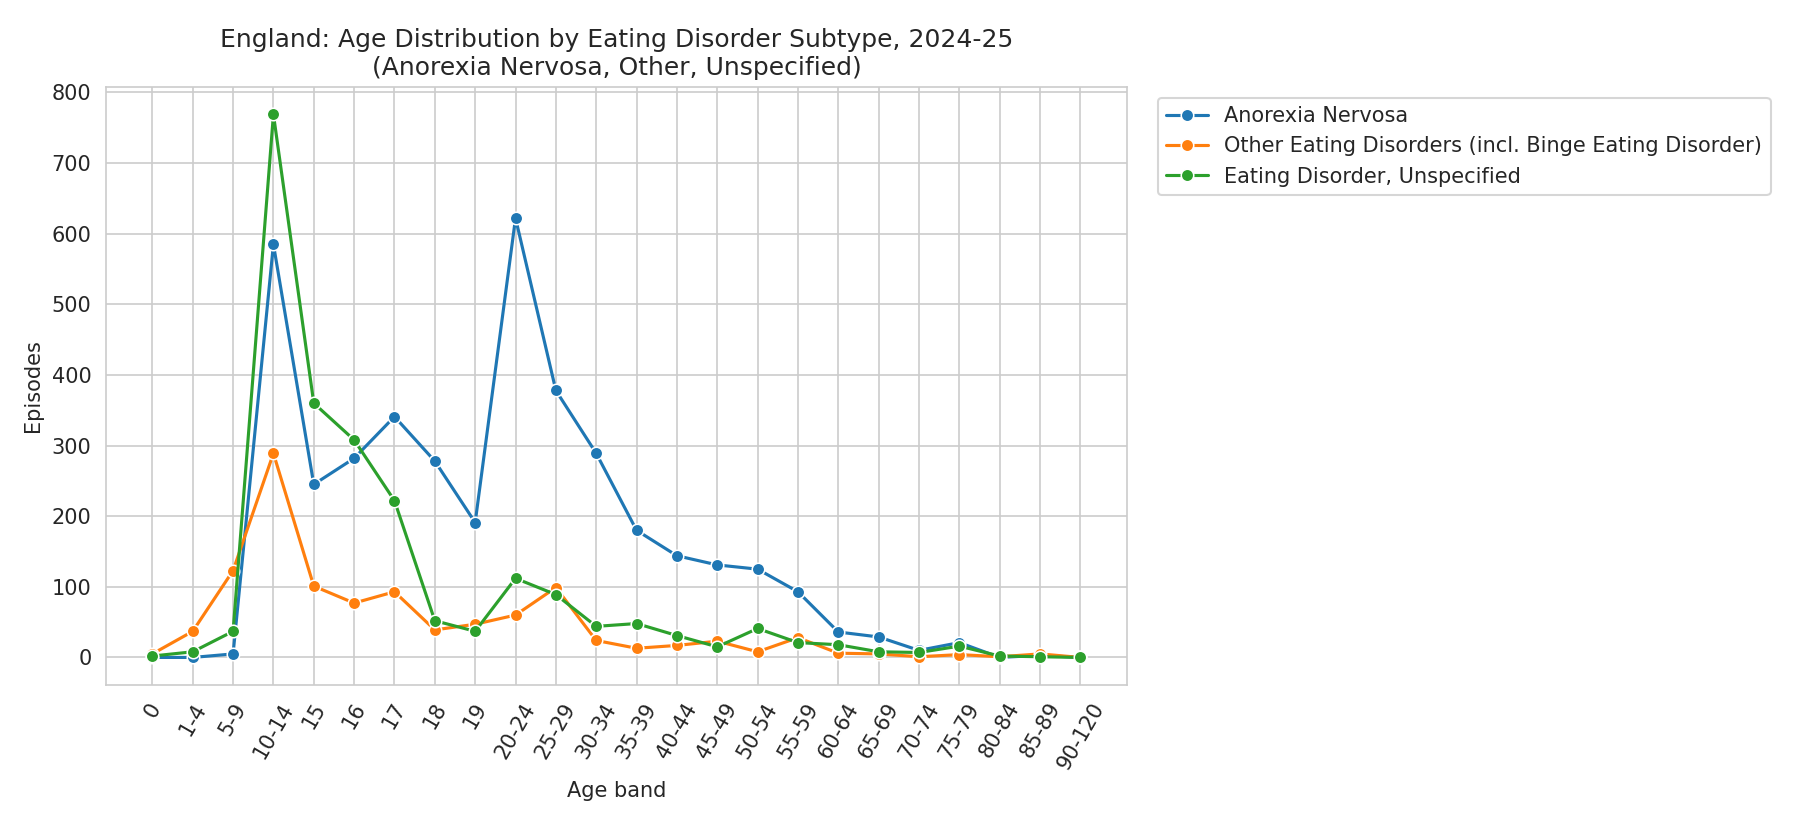

In [ ]:
age = pd.read_csv('data/processed/nhs_ed_age_breakdown_2024-25.csv')
Image('reports/figures/nhs_age_pattern.png')

**Reading this:** there's a sharp admission spike at ages 10–14 across *all* subtypes — likely reflecting both genuine onset patterns and increased clinical/parental vigilance at this age. Anorexia Nervosa specifically shows a **second, distinct peak at ages 20–24**, which the other subtypes don't show as strongly — worth digging into with multi-year data to see if this is a stable pattern.

## 5. Admission urgency

In [ ]:
d2 = subtypes[subtypes['Code'] != 'F50']
emergency_share = d2['FAE_EMERGENCY_Sum'].sum() / d2['FAE_SUM'].sum() * 100
day_case_share = d2['FCE_DAY_CASES'].sum() / d2['FCE_SUM'].sum() * 100
print(f"Emergency admission share: {emergency_share:.1f}%")
print(f"Day case rate: {day_case_share:.1f}%")

Emergency admission share: 82.4%
Day case rate: 3.6%


**Reading this:** 82.4% of admissions are emergency, not planned. This is a striking figure — consistent with eating disorders often reaching a physical or psychiatric crisis point before treatment begins, rather than being caught and managed proactively through planned care.

## Takeaways

- Anorexia Nervosa dominates by volume and is overwhelmingly female (94%)
- A large "Unspecified" category signals a coding/data-quality story worth mentioning in any write-up
- Two distinct age peaks (10-14, and 20-24 for Anorexia specifically)
- The overwhelming emergency-admission share is arguably the most policy-relevant finding here

